# How Interestingness Measures Shapes Association Rule Mining 

Tamanna Pathak

24175478


### Dataset
UCI Online Retail II: https://archive.ics.uci.edu/dataset/502/online+retail+ii  
Chen, D., Sain, S.L., & Guo, K. (2012). Data mining for the online retail industry. *Journal of Database Marketing & Customer Strategy Management*, 19(3), 197–208.

##  Setup and Installation

In [4]:
!pip install mlxtend pandas numpy matplotlib seaborn openpyxl scipy

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

# colour-blind friendly palatte
CB_PALETTE = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#56B4E9', '#D55E00', '#F0E442', '#000000']
plt.rcParams.update({'font.size': 13,'axes.titlesize': 14,'axes.labelsize': 13,'xtick.labelsize': 12,
'ytick.labelsize': 12,'figure.dpi': 120})

## 1 Example of Associative Rule Mining



In [6]:
import pandas as pd
import numpy as np
#step 1: transaction setup and threshold
transactions = { 'T1': ['Bread', 'Butter', 'Milk'],'T2': ['Bread', 'Butter'],'T3': ['Bread', 'Milk'],
    'T4': ['Bread', 'Butter', 'Jam'],'T5': ['Butter', 'Milk'],'T6': ['Bread', 'Jam'],
    'T7': ['Bread', 'Butter'],'T8': ['Milk', 'Jam'],}

all_items = ['Bread', 'Butter', 'Milk', 'Jam']
N = len(transactions)  

item_counts  = {item: sum(1 for t in transactions.values() if item in t) for item in all_items}
item_support = {item: count / N for item, count in item_counts.items()}

freq_df = pd.DataFrame({'Item':list(item_counts.keys()),'Count': list(item_counts.values()),
'Support P(item)': [round(v, 3) for v in item_support.values()]})

print('Step 1: Item Frequencies  (N = 8 transactions)\n')
print(freq_df.to_string(index=False))

MIN_SUP = 0.50
frequent_items = {k: v for k, v in item_support.items() if v >= MIN_SUP}
print(f'\nFrequent items (support >= {MIN_SUP}): {list(frequent_items.keys())}')


Step 1: Item Frequencies  (N = 8 transactions)

  Item  Count  Support P(item)
 Bread      6            0.750
Butter      5            0.625
  Milk      4            0.500
   Jam      3            0.375

Frequent items (support >= 0.5): ['Bread', 'Butter', 'Milk']


In [7]:
from itertools import combinations


print('Step 2: Check Frequent Pairs (support >= 0.50)\n')

for (A, B) in combinations(frequent_items.keys(), 2):
    cnt = sum(1 for t in transactions.values() if A in t and B in t)
    sup = cnt / N
    tag = 'frequent' if sup >= MIN_SUP else 'below threshold'
    print(f'  {{{A}, {B}}}: count={cnt}, support={sup:.3f}  [{tag}]')

# the frequent pair
A,B= 'Bread', 'Butter'
n_AB= sum(1 for t in transactions.values() if A in t and B in t)  # 4
sup_AB= n_AB/N     
sup_A= item_support[A] 
sup_B= item_support[B] 

print(f'\nFrequent pair: {{{A}, {B}}}  (appears in T1, T2, T4, T7)')


Step 2: Check Frequent Pairs (support >= 0.50)

  {Bread, Butter}: count=4, support=0.500  [frequent]
  {Bread, Milk}: count=2, support=0.250  [below threshold]
  {Butter, Milk}: count=2, support=0.250  [below threshold]

Frequent pair: {Bread, Butter}  (appears in T1, T2, T4, T7)


In [8]:
# Step 3: Compute all five measures for both candidate rules 

conf_AB= sup_AB/sup_A          
conf_BA= sup_AB/sup_B        
lift_val= sup_AB/(sup_A * sup_B)
leverage= sup_AB-sup_A * sup_B
kulc= 0.5*(conf_AB+conf_BA)
cosine=sup_AB/np.sqrt(sup_A*sup_B)
conv_AB=(1-sup_B)/(1 - conf_AB)
conv_BA=(1-sup_A)/(1 - conf_BA)


print('Step 3: All Five Measures for Both Candidate Rules\n\n')


results = pd.DataFrame({'Rule':['Bread -> Butter', 'Butter -> Bread'],'Support':[round(sup_AB, 3),  round(sup_AB, 3)],
'Confidence':[round(conf_AB, 3), round(conf_BA, 3)],'Lift':[round(lift_val, 3), round(lift_val, 3)],
'Leverage':[round(leverage, 3), round(leverage, 3)],'Conviction':[round(conv_AB, 3),  round(conv_BA, 3)],
'Kulczynski':[round(kulc, 3),     round(kulc, 3)],'Cosine':[round(cosine, 3),   round(cosine, 3)],})
print(results.to_string(index=False))

print('\nKey observations:')
print(f'Confidence is not symmetric: Butter->Bread ({conf_BA:.3f}) > Bread->Butter ({conf_AB:.3f})')
print(f'Lift is symmetric:{lift_val:.3f} in both directions')
print(f'Kulczynski ={kulc:.3f}(> 0.5 confirms positive association and null invariant)')
print(f'Cosine = {cosine:.3f} (null invariant)')


Step 3: All Five Measures for Both Candidate Rules


           Rule  Support  Confidence  Lift  Leverage  Conviction  Kulczynski  Cosine
Bread -> Butter      0.5       0.667 1.067     0.031       1.125       0.733    0.73
Butter -> Bread      0.5       0.800 1.067     0.031       1.250       0.733    0.73

Key observations:
Confidence is not symmetric: Butter->Bread (0.800) > Bread->Butter (0.667)
Lift is symmetric:1.067 in both directions
Kulczynski =0.733(> 0.5 confirms positive association and null invariant)
Cosine = 0.730 (null invariant)


## 2. Load and Clean the Dataset

In [9]:
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010', engine='openpyxl')
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [10]:
df.dropna(subset=['Customer ID', 'Description'], inplace=True)
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df = df[df['Country'] == 'United Kingdom']
df['Description'] = df['Description'].str.strip().str.upper()
print(f"Cleaned shape: {df.shape}")
print(f"Unique invoices: {df['Invoice'].nunique()}")
print(f"Unique products: {df['Description'].nunique()}")

Cleaned shape: (370929, 8)
Unique invoices: 17612
Unique products: 4376


## 3. Building the Transaction Basket Matrix

 The transactional data is converted into a **basket matrix**: one row per invoice, one column per product, `True` if the product appeared in that invoice.

In [11]:
# Keeping only the top N most frequent items
TOP_N = 100
top_items = df['Description'].value_counts().head(TOP_N).index.tolist()
df_top = df[df['Description'].isin(top_items)]

# Group by invoice and collect items as lists
basket = df_top.groupby('Invoice')['Description'].apply(list).tolist()

# Encoding into binary matrix
te = TransactionEncoder()
te_array = te.fit_transform(basket)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Basket matrix shape: {basket_df.shape}")
print(f"(rows = invoices, columns = products)")
basket_df.head(3)

Basket matrix shape: (14084, 100)
(rows = invoices, columns = products)


,6 RIBBONS RUSTIC CHARM,60 TEATIME FAIRY CAKE CASES,72 SWEETHEART FAIRY CAKE CASES,ANTIQUE SILVER TEA GLASS ETCHED,ASSORTED COLOUR BIRD ORNAMENT,BAKING SET 9 PIECE RETROSPOT,BATHROOM METAL SIGN,CHOCOLATE HOT WATER BOTTLE,COLOUR GLASS T-LIGHT HOLDER HANGING,COOK WITH WINE METAL SIGN,...,VINTAGE HEADS AND TAILS CARD GAME,VINTAGE SNAP CARDS,VINTAGE UNION JACK BUNTING,VINTAGE UNION JACK CUSHION COVER,WHITE HANGING HEART T-LIGHT HOLDER,WOOD 2 DRAWER CABINET WHITE FINISH,WOOD S/3 CABINET ANT WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,ZINC METAL HEART DECORATION
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


## 4. Mine Frequent Itemsets with FP Growth

**FP Growth** is used to avoid repeated database scans by compressing the transaction database into a compact FP-tree structure, making it significantly faster for dense datasets

In [12]:
MIN_SUPPORT = 0.02 

frequent_itemsets = fpgrowth(basket_df, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")
print(frequent_itemsets['length'].value_counts().sort_index().rename('count').to_frame())

Frequent itemsets found: 155
   count
1    100
2     55


## 5. Generate Association Rules

From the frequent itemsets,ules are generated  using a minimum confidence threshold, then all interestingness measures for each rule are computed .

In [13]:
MIN_CONFIDENCE = 0.3

rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=MIN_CONFIDENCE)
print(f"Rules generated: {len(rules)}")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5)

Rules generated: 97


,antecedents,consequents,support,confidence,lift
0,(ASSORTED COLOUR BIRD ORNAMENT),(WHITE HANGING HEART T-LIGHT HOLDER),0.026910,0.300794,1.450814
1,(HOME BUILDING BLOCK WORD),(WHITE HANGING HEART T-LIGHT HOLDER),0.027336,0.338610,1.633215
2,(HOME BUILDING BLOCK WORD),(LOVE BUILDING BLOCK WORD),0.036424,0.451187,6.825481
3,(LOVE BUILDING BLOCK WORD),(HOME BUILDING BLOCK WORD),0.036424,0.551020,6.825481
4,(LOVE BUILDING BLOCK WORD),(WHITE HANGING HEART T-LIGHT HOLDER),0.025916,0.392052,1.890977


## 6. Compute Additional Interestingness Measures

 four additional measures beyond lift:

| Measure | Formula | Null-invariant? |
|---|---|---|
| **Lift** | P(A∪B) / (P(A)·P(B)) | No |
| **Leverage** | P(A∪B) − P(A)·P(B) | No |
| **Conviction** | (1 − P(B)) / (1 − confidence) | No |
| **Kulczynski** | 0.5·(P(A/B) + P(B/A)) | Yes |
| **Cosine** | P(A∪B) / sqrt(P(A)·P(B)) | Yes |

In [14]:
def compute_kulczynski(rules):
    """Kulczynski measure: average of both conditional probabilities."""
    conf_AB = rules['confidence']          
    conf_BA = rules['support'] / rules['consequent support'] 
    return 0.5 * (conf_AB + conf_BA)

def compute_cosine(rules):
    """Cosine measure: geometric mean of both conditional probabilities."""
    return rules['support'] / np.sqrt(rules['antecedent support'] * rules['consequent support'])

rules['kulczynski']=compute_kulczynski(rules)
rules['cosine']=compute_cosine(rules)

measures = ['lift', 'leverage', 'conviction', 'kulczynski', 'cosine']
print("Summary of all interestingness measures:\n")
rules[measures].describe().round(4)

Summary of all interestingness measures:



,lift,leverage,conviction,kulczynski,cosine
count,97.0000,97.0000,97.0000,97.0000,97.0000
mean,7.1430,0.0203,1.6955,0.4161,0.4082
std,2.9800,0.0054,0.4040,0.0905,0.0966
min,1.4508,0.0084,1.1337,0.2153,0.1976
25%,5.8686,0.0179,1.4486,0.3662,0.3661
50%,6.8549,0.0190,1.5906,0.4049,0.3952
75%,8.1086,0.0218,1.8028,0.4695,0.4505
max,15.1629,0.0366,3.8500,0.6194,0.6160


## 7. The Null Invariance Problem With Toy Example

Scenario:A supermarket has 10,000 transactions. Consider items A and B.

In [15]:
 '''Two scenarios: one where A and B are genuinely associated and the other
 where they are not ,but null transactions differ dramatically.'''

def compute_measures_from_counts(n11, n10, n01, n00):
    """n11 = both A and B present
    n10 = A present, B absent
    n01 = A absent, B present
    n00 = neither present (null transactions)
    """
    N=n11+n10+n01+n00
    pA=(n11 + n10)/ N
    pB=(n11 + n01)/ N
    pAB=n11/N

    lift=pAB/(pA*pB) if (pA*pB)>0 else np.nan
    conf_AB=pAB/pA if pA> 0 else np.nan  
    conf_BA=pAB/pB if pB> 0 else np.nan   
    leverage= pAB - pA * pB
    cosine_val= pAB/np.sqrt(pA*pB) if (pA*pB)> 0 else np.nan
    kulc_val=0.5*(conf_AB + conf_BA)

    return {'n11': n11, 'n10': n10, 'n01': n01, 'n00': n00, 'N': N,'P(A)': round(pA,3), \
        'P(B)': round(pB,3), 'P(A∩B)': round(pAB,4),'Lift': round(lift,3),
        'Confidence P(B|A)': round(conf_AB,3),'Leverage': round(leverage,4),
        'Cosine': round(cosine_val,3),'Kulczynski': round(kulc_val,3)}

# Scenario 1: Moderate association, few null transactions
s1 = compute_measures_from_counts(n11=300, n10=700, n01=200, n00=800)

# Scenario 2: Same counts, but many null transactions added
s2 = compute_measures_from_counts(n11=300, n10=700, n01=200, n00=8800)

comparison = pd.DataFrame([s1, s2], index=['Scenario 1 (few nulls)', 'Scenario 2 (many nulls)'])
print(comparison[['n11','n10','n01','n00','N','P(A)','P(B)','P(A∩B)',
                   'Lift','Confidence P(B|A)','Leverage','Cosine','Kulczynski']].T)

                   Scenario 1 (few nulls)  Scenario 2 (many nulls)
n11                               300.000                  300.000
n10                               700.000                  700.000
n01                               200.000                  200.000
n00                               800.000                 8800.000
N                                2000.000                10000.000
P(A)                                0.500                    0.100
P(B)                                0.250                    0.050
P(A∩B)                              0.150                    0.030
Lift                                1.200                    6.000
Confidence P(B|A)                   0.300                    0.300
Leverage                            0.025                    0.025
Cosine                              0.424                    0.424
Kulczynski                          0.450                    0.450


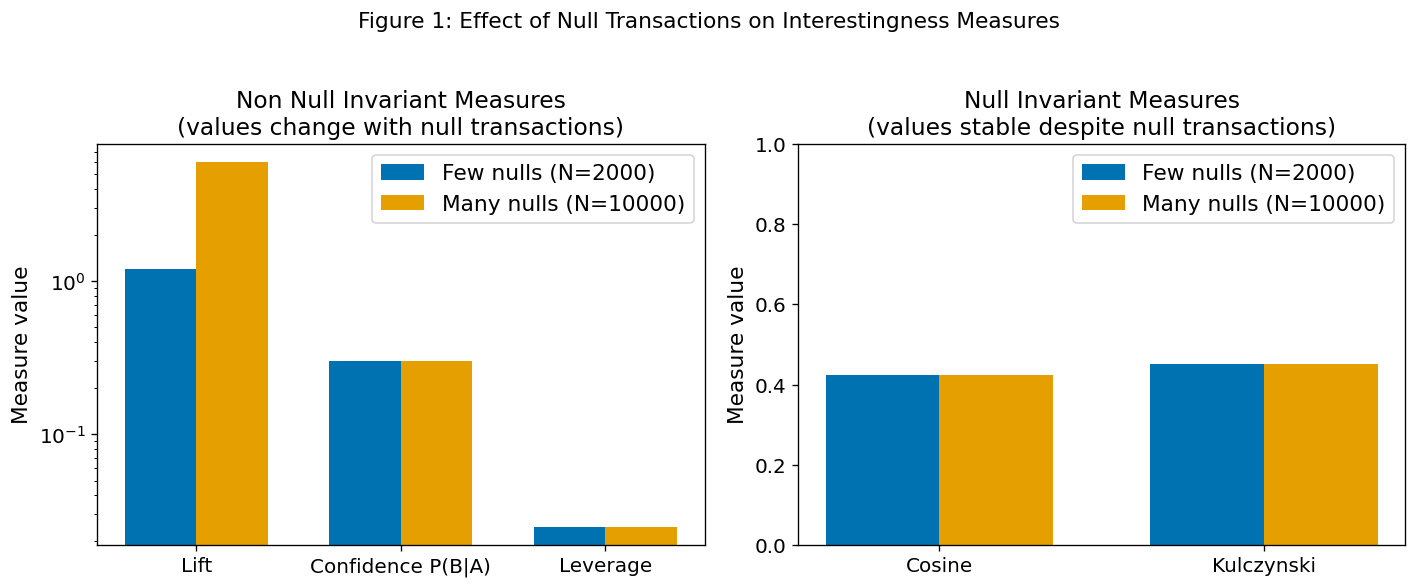

Bar chart with two panels. Left panel shows Lift, Confidence, and Leverage for two scenarios with identical A and B occurrences but different null transaction counts. Values change substantially. Right panel shows Cosine and Kulczynski for the same scenarios,values remain identical due to null invariance.


In [16]:
# Figure 1: Bar chart showing null invariance problem
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

non_invariant=['Lift','Confidence P(B|A)','Leverage']
invariant=['Cosine','Kulczynski']

s1_vals_ni=[s1[m] for m in non_invariant]
s2_vals_ni=[s2[m] for m in non_invariant]
s1_vals_i=[s1[m] for m in invariant]
s2_vals_i=[s2[m] for m in invariant]

x1 = np.arange(len(non_invariant))
x2 = np.arange(len(invariant))
w  = 0.35

# Non invariant measures
axes[0].bar(x1 - w/2, s1_vals_ni, w, label='Few nulls (N=2000)',  color=CB_PALETTE[0])
axes[0].bar(x1 + w/2, s2_vals_ni, w, label='Many nulls (N=10000)', color=CB_PALETTE[1])
axes[0].set_xticks(x1)
axes[0].set_xticklabels(non_invariant)
axes[0].set_title('Non Null Invariant Measures\n(values change with null transactions)')
axes[0].set_yscale('log')
axes[0].set_ylabel('Measure value')
axes[0].legend()
axes[0].set_ylim(bottom=0)

# Invariant measures
axes[1].bar(x2 - w/2, s1_vals_i, w, label='Few nulls (N=2000)',  color=CB_PALETTE[0])
axes[1].bar(x2 + w/2, s2_vals_i, w, label='Many nulls (N=10000)', color=CB_PALETTE[1])
axes[1].set_xticks(x2)
axes[1].set_xticklabels(invariant)
axes[1].set_title('Null Invariant Measures\n(values stable despite null transactions)')
axes[1].set_ylabel('Measure value')
axes[1].legend()
axes[1].set_ylim(0, 1)

fig.suptitle('Figure 1: Effect of Null Transactions on Interestingness Measures\n', fontsize=13)
plt.tight_layout()
plt.savefig('fig1_null_invariance.png', bbox_inches='tight', dpi=150)
plt.show()
print("Bar chart with two panels. Left panel shows Lift, Confidence, and Leverage "
      "for two scenarios with identical A and B occurrences but different null transaction counts. "
      "Values change substantially. Right panel shows Cosine and Kulczynski for the same "
      "scenarios,values remain identical due to null invariance.")

## 8. Empirical Comparison: Which Rules Do Different Measures Prefer?

In [17]:

rules['conviction'] = rules['conviction'].replace([np.inf, -np.inf], 99).clip(upper=99)

TOP_K = 20

top_indices = {}
for m in measures:
    top_indices[m] = set(rules[m].nlargest(TOP_K).index)
overlap = pd.DataFrame(index=measures, columns=measures, dtype=int)
for m1 in measures:
    for m2 in measures:
        overlap.loc[m1, m2] = len(top_indices[m1] & top_indices[m2])

print("Top 20 rule overlap between measures:")
print(overlap)

Top 20 rule overlap between measures:
            lift  leverage  conviction  kulczynski  cosine
lift        20.0       7.0        12.0        14.0    14.0
leverage     7.0      20.0         9.0        12.0    12.0
conviction  12.0       9.0        20.0        14.0    14.0
kulczynski  14.0      12.0        14.0        20.0    20.0
cosine      14.0      12.0        14.0        20.0    20.0


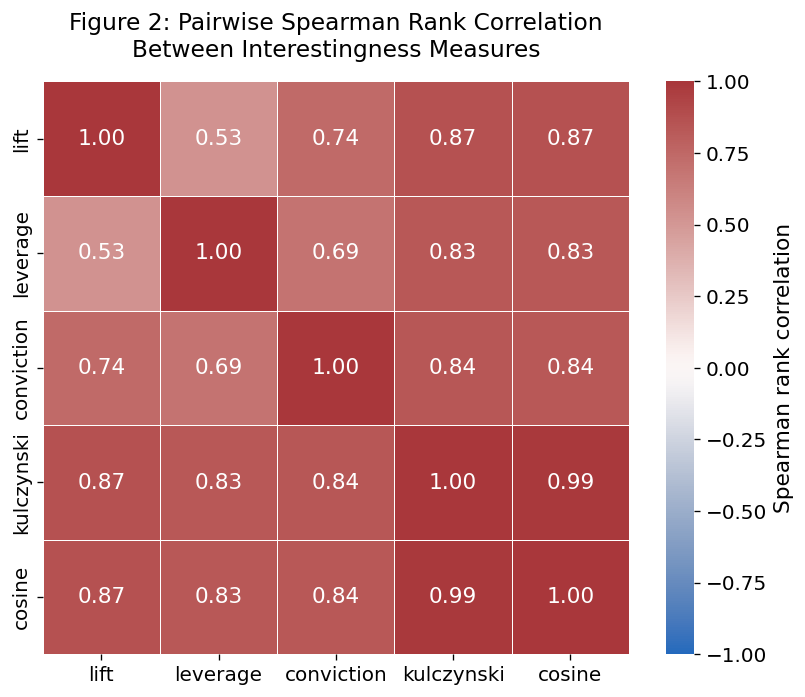

Heatmap showing 5x5 Spearman rank correlation matrix between lift, leverage, conviction, kulczynski, and cosine.


In [22]:
#Figure 2: Heatmap showing correlation
rank_corr = rules[measures].rank().corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.zeros_like(rank_corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

cmap = sns.color_palette("vlag", as_cmap=True)

sns.heatmap(rank_corr,annot=True,fmt='.2f',cmap=cmap,vmin=-1, vmax=1,linewidths=0.5,ax=ax,
cbar_kws={'label': 'Spearman rank correlation'})
ax.set_title('Figure 2: Pairwise Spearman Rank Correlation\nBetween Interestingness Measures', pad=15)
plt.tight_layout()
plt.savefig('fig2_rank_correlation.png', bbox_inches='tight', dpi=150)
plt.show()
print("Heatmap showing 5x5 Spearman rank correlation matrix between lift, leverage, "
      "conviction, kulczynski, and cosine.")

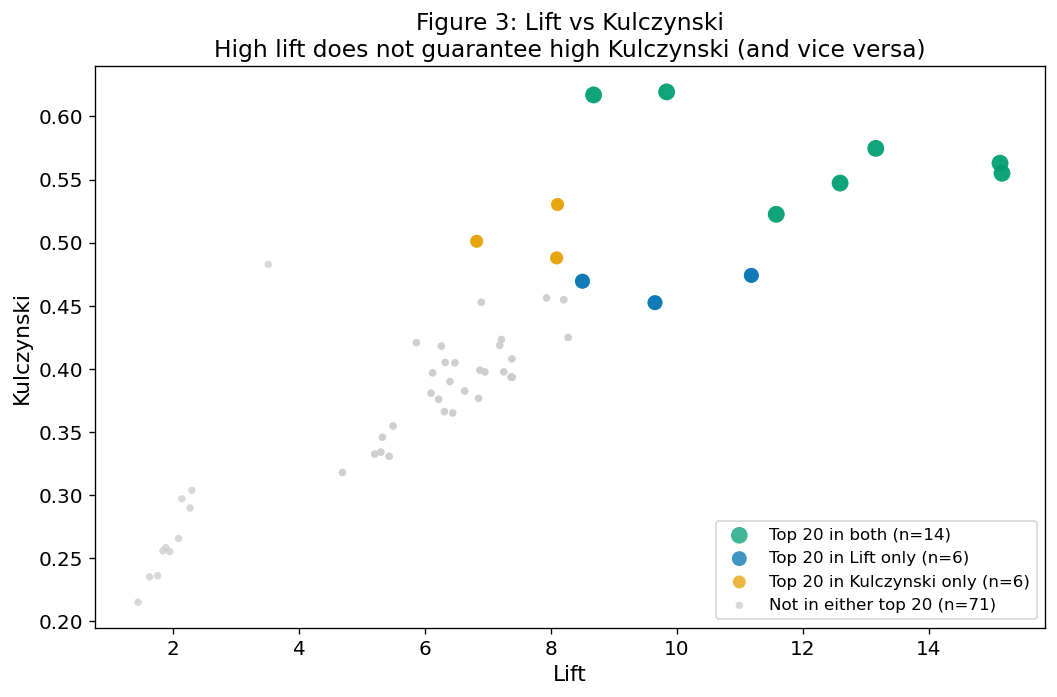

Scatter plot of lift (x=axis) vs Kulczynski (y-axis) for all rules. Points coloured by whether they appear in the top 20 under lift only (blue), Kulczynski only (orange), both (green), or neither (grey). Demonstrates that top ranked rules differ substantially between the two measures.


In [19]:
#Figure 3: Life vs kulczynski in top 20
in_lift_top = rules.index.isin(top_indices['lift'])
in_kulc_top = rules.index.isin(top_indices['kulczynski'])

def label_rule(lift_in, kulc_in):
    if lift_in and kulc_in:return 'Top 20 in both'
    elif lift_in:return 'Top 20 in Lift only'
    elif kulc_in:return "Top 20 in Kulczynski only"
    else:return 'Not in either top 20'

rules['group']=[label_rule(l, k) for l, k in zip(in_lift_top, in_kulc_top)]

colour_map = {'Top 20 in both': CB_PALETTE[2],'Top 20 in Lift only': CB_PALETTE[0], 
    'Top 20 in Kulczynski only': CB_PALETTE[1],'Not in either top 20':'#cccccc'}
size_map = {'Top 20 in both': 100,'Top 20 in Lift only': 80,'Top 20 in Kulczynski only': 60,
           'Not in either top 20': 20}

fig, ax = plt.subplots(figsize=(9, 6))

for grp, colour in colour_map.items():
        subset = rules[rules['group'] == grp]
        ax.scatter(subset['lift'], subset['kulczynski'],c=colour, s=size_map[grp],
        label=f"{grp} (n={len(subset)})",alpha=0.75, edgecolors='none')

ax.set_xlabel('Lift')
ax.set_ylabel('Kulczynski')
ax.set_title('Figure 3: Lift vs Kulczynski\n'
             'High lift does not guarantee high Kulczynski (and vice versa)')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('fig3_lift_vs_kulczynski.png', bbox_inches='tight', dpi=150)
plt.show()
print("Scatter plot of lift (x=axis) vs Kulczynski (y-axis) for all rules. "
      "Points coloured by whether they appear in the top 20 under lift only (blue), "
      "Kulczynski only (orange), both (green), or neither (grey). Demonstrates that "
      "top ranked rules differ substantially between the two measures.")

## 9. Table of Top 5 Rules Under Each Measure

Comparison table is created where we have the same dataset, but the top rule changes depending on which measure you use.

In [20]:
def format_rule(row):
    ant = ", ".join(list(row["antecedents"]))
    con = ", ".join(list(row["consequents"]))
    if len(ant) > 45: ant = ant[:42] + "..."
    if len(con) > 35: con = con[:32] + "..."
    return f"{ant} → {con}"

results = []
for m in measures:
    cols = ["antecedents", "consequents", "support", "confidence","lift", "kulczynski", "cosine", m]
    top5 = rules.nlargest(5, m)[cols].copy()
    top5 = top5.loc[:, ~top5.columns.duplicated()]  
    top5 = top5.rename(columns={m: "Score"})       
    top5["Score"] = top5["Score"].round(3)
    for col in ["lift", "kulczynski", "cosine"]:
        if col not in top5.columns:
            top5[col]=rules.loc[top5.index, col]
    top5["Rule"]= top5.apply(format_rule, axis=1)
    top5["Measure"]= m
    top5["Rank"]=range(1, 6)
    results.append(top5[["Measure", "Rank", "Rule", "Score","support", "confidence", 
                         "lift", "kulczynski", "cosine"]])

top5_table = pd.concat(results)
summary = top5_table[top5_table["Rank"] == 1].reset_index(drop=True)
summary[["Measure", "Rule", "Score", "support", "confidence", "lift", "kulczynski", "cosine"]]


,Measure,Rule,Score,support,confidence,lift,kulczynski,cosine
0,lift,HAND WARMER BIRD DESIGN → HAND WARMER OWL DESIGN,15.163,0.020307,0.565217,15.162899,0.554990,0.554895
1,leverage,SWEETHEART CERAMIC TRINKET BOX → STRAWBERRY CE...,0.037,0.041394,0.763089,8.681216,0.617005,0.599462
2,conviction,SWEETHEART CERAMIC TRINKET BOX → STRAWBERRY CE...,3.850,0.041394,0.763089,8.681216,0.617005,0.599462
3,kulczynski,WOODEN FRAME ANTIQUE WHITE → WOODEN PICTURE FR...,0.619,0.038554,0.554082,9.840713,0.619412,0.615957
4,cosine,WOODEN FRAME ANTIQUE WHITE → WOODEN PICTURE FR...,0.616,0.038554,0.554082,9.840713,0.619412,0.615957


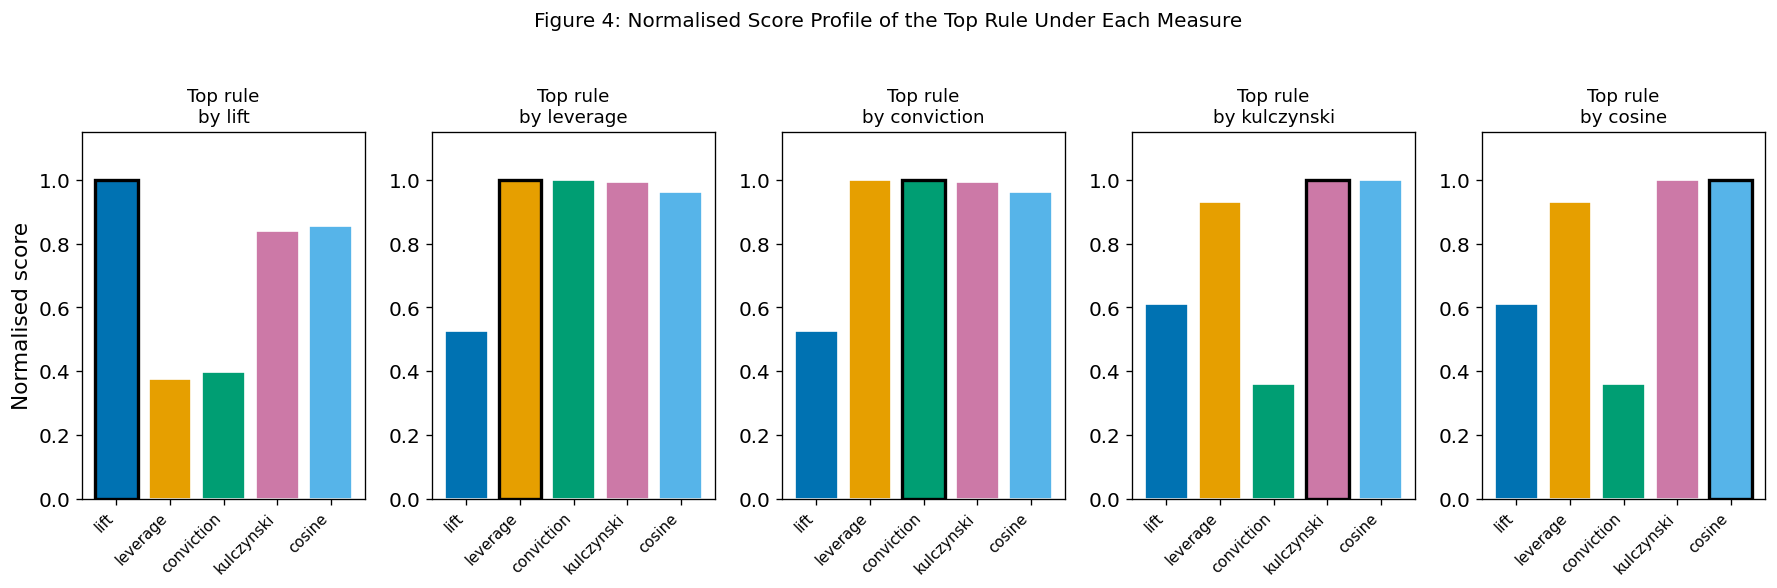

Five bar charts that shows the normalised score profile (across all five measures) of the top ranked rule under each respective measure


In [23]:
# Figure 4:the top rule under each measure

rules_norm = rules[measures].copy()
for m in measures:
    col = rules_norm[m]
    rules_norm[m] =(col-col.min())/(col.max()-col.min()+ 1e-9)

fig, axes=plt.subplots(1,5,figsize=(15,5), sharey=False)

for ax, m in zip(axes, measures):
    top_idx = rules[m].idxmax()
    scores = rules_norm.loc[top_idx, measures].values
    bars = ax.bar(measures, scores, color=CB_PALETTE[:5], edgecolor='white')
    ax.set_title(f'Top rule\nby {m}', fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_xticklabels(measures, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Normalised score' if ax == axes[0] else '')

    bars[measures.index(m)].set_edgecolor('black')
    bars[measures.index(m)].set_linewidth(2)

fig.suptitle('Figure 4: Normalised Score Profile of the Top Rule Under Each Measure\n',fontsize=12)
plt.tight_layout()
plt.savefig('fig4_top_rule_profiles.png', bbox_inches='tight', dpi=150)
plt.show()
print("Five bar charts that shows the normalised score profile "
      "(across all five measures) of the top ranked rule under each respective measure")

## 10. When to use which measure

| Situation | Recommended measure | Why |
|---|---|---|
| Rare items in a large catalogue | Kulczynski or Cosine | Null invariant, unaffected by catalogue size |
| Balanced, dense transactions | Lift or Leverage | Intuitive,understood |
| Need directional strength | Conviction | Penalises rules where consequent is nearly certain anyway |
| Unknown data properties | Compute all and compare | Disagreement signals interesting structure |
